In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib import cm as cm

#Load the dataset using pandas
data = pd.read_csv('winequality-red.csv', delimiter=';')

#Extract features (removes the "quality" column)
wine_data = data.iloc[:, :-1]
wine_array = np.array(wine_data)

#THESE 2 PRINT STATEMENTS ARE FOR DEBUGGING - They show the dimensions and layout of the original matrix
print(wine_array) #Prints data in an array
print("Dimensions: ", wine_array.shape, "\n")

[[ 7.4    0.7    0.    ...  3.51   0.56   9.4  ]
 [ 7.8    0.88   0.    ...  3.2    0.68   9.8  ]
 [ 7.8    0.76   0.04  ...  3.26   0.65   9.8  ]
 ...
 [ 6.3    0.51   0.13  ...  3.42   0.75  11.   ]
 [ 5.9    0.645  0.12  ...  3.57   0.71  10.2  ]
 [ 6.     0.31   0.47  ...  3.39   0.66  11.   ]]
Dimensions:  (1599, 11) 



In [2]:
#Part I: Basic Stats
#Mean
mean_array = np.empty(wine_array.shape[1]) #wine_array.shape[1] is 11 because the 2nd dimension is 11 columns
mean_array = wine_array.sum(axis=0, dtype='float')
mean_array = mean_array / len(wine_array)
print("PART I:")
print("a.\nMean Array =", mean_array)

#Finding the mean using numpy
print("NP Test =   ", np.mean(wine_array, axis=0))

PART I:
a.
Mean Array = [ 8.31963727  0.52782051  0.27097561  2.5388055   0.08746654 15.87492183
 46.46779237  0.99674668  3.3111132   0.65814884 10.42298311]
NP Test =    [ 8.31963727  0.52782051  0.27097561  2.5388055   0.08746654 15.87492183
 46.46779237  0.99674668  3.3111132   0.65814884 10.42298311]


In [3]:
#Variance
print("b.")
variance = 0.0
for row in wine_array:
    variance = variance + np.linalg.norm(row - mean_array) ** 2
variance = variance/len(wine_array)
print("Variance(D) =", variance)

#Finding the variance using numpy
variance = 0.0
for i in np.var(wine_array, axis=0):
    variance = variance + i
print("   NP Test = ", variance)

b.
Variance(D) = 1197.047922329169
   NP Test =  1197.0479223291695


In [5]:
#Sample Covariance Matrix
#Note: Should be 11x11 (due to centered matrix)

print("c.")
cov_matrix = np.cov(wine_array, rowvar=False, bias=True)
print("NP Test for Covarience Matrix: ", cov_matrix)
print("")

#Create Center Matrix
centered_matrix = wine_array - mean_array.T

#Inner Product Matrix
inner_product = np.dot(np.transpose(centered_matrix), centered_matrix)
inner_product = inner_product / len(wine_array)
print("Covariance Matrix using Inner Product = ", inner_product, "\n")

#Outer Product Matrix
outer_product = 0.0
for row in centered_matrix:
    newRow = row[:,None]
    outer_product = outer_product + np.dot(newRow, newRow.T)
outer_product = outer_product / len(wine_array)
print("Covariance Matrix using Outer Product = ", outer_product)

c.
NP Test for Covarience Matrix:  [[ 3.02952057e+00 -7.98014785e-02  2.27677527e-01  2.81580055e-01
   7.67389030e-03 -2.79916982e+00 -6.47829186e+00  2.19385070e-03
  -1.83470891e-01  5.39763142e-02 -1.14349595e-01]
 [-7.98014785e-02  3.20423261e-02 -1.92595685e-02  4.83888167e-04
   5.16263851e-04 -1.96612867e-02  4.50144000e-01  7.43900996e-06
   6.49063758e-03 -7.91647985e-03 -3.85760812e-02]
 [ 2.27677527e-01 -1.92595685e-02  3.79237511e-02  3.94096081e-02
   1.86755609e-03 -1.24174408e-01  2.27554874e-01  1.34090669e-04
  -1.62873900e-02  1.03212557e-02  2.28009045e-02]
 [ 2.81580055e-01  4.83888167e-04  3.94096081e-02  1.98665392e+00
   3.68786810e-03  2.75688624e+00  9.41055252e+00  9.44819611e-04
  -1.86326290e-02  1.32011525e-03  6.31794232e-02]
 [ 7.67389030e-03  5.16263851e-04  1.86755609e-03  3.68786810e-03
   2.21375732e-03  2.73659057e-03  7.33408548e-02  1.78106112e-05
  -1.92454062e-03  2.96002562e-03 -1.10845812e-02]
 [-2.79916982e+00 -1.96612867e-02 -1.24174408e-01 

In [54]:
#Correlation matrix
correlation_matrix = np.zeros((wine_array.shape[1], wine_array.shape[1]))
for Col1 in range(0, wine_array.shape[1]-1):
    for Col2 in range(Col1+1, wine_array.shape[1]):
        Z_1 = wine_array[:,Col1] - np.mean(wine_array[:,Col1])
        Z_2 = wine_array[:,Col2] - np.mean(wine_array[:,Col2])
        correlation = np.dot(np.transpose((Z_1 / np.linalg.norm(Z_1))), (Z_2 / np.linalg.norm(Z_2)))
        correlation_matrix[Col1][Col2] = correlation
        correlation_matrix[Col2][Col1] = correlation
print("Part D.\nCorrelation_matrix: \n", correlation_matrix)

Part D.
Correlation_matrix: 
 [[ 0.         -0.25613089  0.67170343  0.11477672  0.09370519 -0.15379419
  -0.11318144  0.66804729 -0.68297819  0.18300566 -0.06166827]
 [-0.25613089  0.         -0.55249568  0.00191788  0.06129777 -0.01050383
   0.07647     0.02202623  0.23493729 -0.26098669 -0.20228803]
 [ 0.67170343 -0.55249568  0.          0.14357716  0.20382291 -0.06097813
   0.03553302  0.36494718 -0.54190414  0.31277004  0.10990325]
 [ 0.11477672  0.00191788  0.14357716  0.          0.05560954  0.187049
   0.20302788  0.35528337 -0.08565242  0.00552712  0.04207544]
 [ 0.09370519  0.06129777  0.20382291  0.05560954  0.          0.00556215
   0.04740047  0.20063233 -0.26502613  0.37126048 -0.22114054]
 [-0.15379419 -0.01050383 -0.06097813  0.187049    0.00556215  0.
   0.66766645 -0.02194583  0.0703775   0.05165757 -0.06940835]
 [-0.11318144  0.07647     0.03553302  0.20302788  0.04740047  0.66766645
   0.          0.07126948 -0.06649456  0.04294684 -0.20565394]
 [ 0.66804729  0.0220

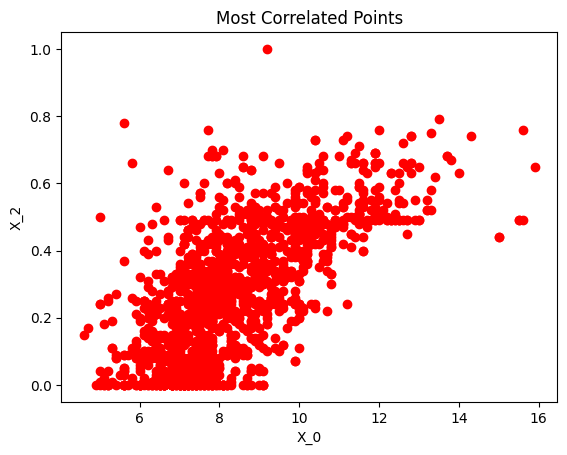

In [28]:
#Plot scatterplots of the most and least correlated data points
#Most Correlated data points
maxi, maxj = np.unravel_index(correlation_matrix.argmax(), correlation_matrix.shape)
most_correlated = [maxi, maxj]
plt.scatter(wine_array[:,[maxi]], wine_array[:,[maxj]], color='red')
plt.title("Most Correlated Points")
plt.xlabel("X_"+str(maxi))
plt.ylabel("X_"+str(maxj))
plt.show()

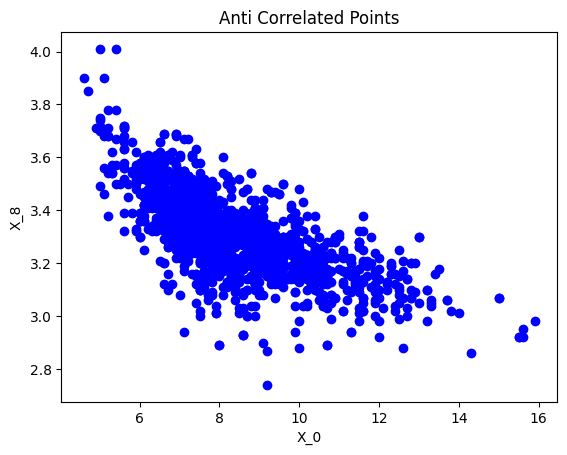

In [27]:
#Anti Correlated data points
mini, minj = np.unravel_index(correlation_matrix.argmin(), correlation_matrix.shape)
anti_correlated = [mini, minj]
plt.scatter(wine_array[:,[mini]], wine_array[:,[minj]], color='blue')
plt.title("Anti Correlated Points")
plt.xlabel("X_"+str(mini))
plt.ylabel("X_"+str(minj))
plt.show()

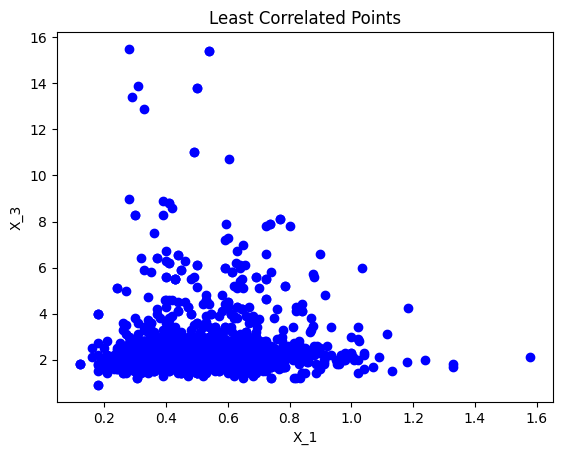

In [29]:
#Least Correlated Data Points 
absolute_corr = np.absolute(correlation_matrix)
mini, minj = np.where( absolute_corr==np.min(absolute_corr[np.nonzero(absolute_corr)]))
mini = mini[0]
minj = minj[0]
least_correlated = [mini, minj]
plt.scatter(wine_array[:,[mini]], wine_array[:,[minj]], color='blue')
plt.title("Least Correlated Points")
plt.xlabel("X_"+str(mini))
plt.ylabel("X_"+str(minj))
plt.show()

In [30]:
#Output for the attributes
print("Amongst attributes 0 to 11, we can make these observations from the correlation matrix:")
print("Most correlated:", most_correlated[0], most_correlated[1])
print("Anti correlated:", anti_correlated[0], anti_correlated[1])
print("Least correlated:", least_correlated[0], least_correlated[1])

Amongst attributes 0 to 11, we can make these observations from the correlation matrix:
Most correlated: 0 2
Anti correlated: 0 8
Least correlated: 1 3


In [129]:
#Part II: Mean via Gradient Descent
#Stochastic Gradient Descent

print("PART II:")

eta = 0.01  #Learning rate
epsilon = 1e-6  #Convergence threshold
max_iterations = 1000  #Maximum number of iterations

#Initialize the estimate of the mean (z) randomly
z = np.random.randn(wine_array.shape[1])

#Stochastic Gradient Descent
for i in range(max_iterations):
    xi = wine_array[np.random.randint(wine_array.shape[0])] #randomly selected data point
    gradient = z - xi
    
    # Update z with gradient descent formula
    z = z - eta * gradient
    
    #Test for convergence
    if np.linalg.norm(gradient) < epsilon:
        print("Converged after", i, "iterations.")
        break

difference_norm = np.linalg.norm(z - mean_array)
print("True Mean:", mean_array)
print("Estimated Mean:", z)
print("Norm of Difference:", difference_norm)


PART II:
True Mean: [ 8.31963727  0.52782051  0.27097561  2.5388055   0.08746654 15.87492183
 46.46779237  0.99674668  3.3111132   0.65814884 10.42298311]
Estimated Mean: [ 8.11190088  0.53482611  0.24725739  2.47302898  0.08712905 16.00577324
 45.09241505  0.99653048  3.32417287  0.66573498 10.40436167]
Norm of Difference: 1.399089872131827


PART III
Estimated Dominant Eigenvalue: 1106.2310379053529
True Dominant Eigenvalue: 1133.8070755113818
Estimated Dominant Eigenvector: [ 6.13247431e-03 -3.84465551e-04 -1.70902595e-04 -8.64894648e-03
 -6.37307290e-05 -2.18857434e-01 -9.75678369e-01 -3.72498542e-06
  2.68008619e-04 -2.23381730e-04  6.35846721e-03]
True Dominant Eigenvector: [ 6.13247431e-03 -3.84465551e-04 -1.70902595e-04 -8.64894648e-03
 -6.37307290e-05 -2.18857434e-01 -9.75678369e-01 -3.72498542e-06
  2.68008619e-04 -2.23381730e-04  6.35846721e-03]


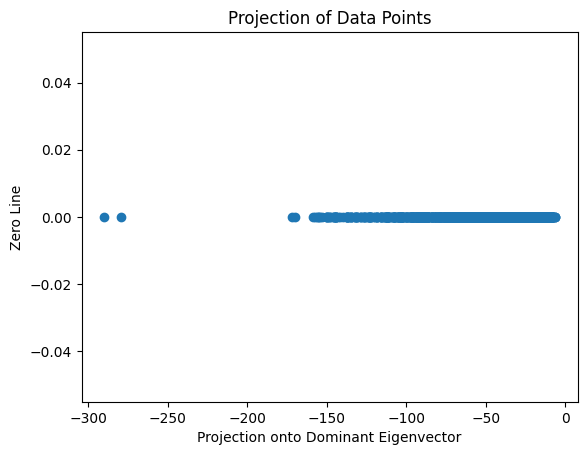

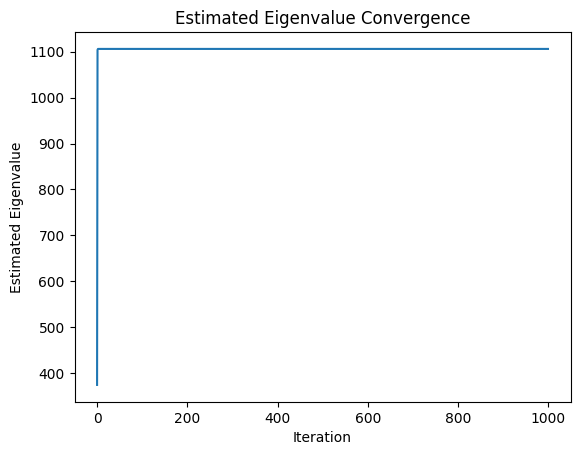

Variance of Projected Points: 1133.0980029188163
Relationship to Dominant Eigenvalue: 1.0242869383454798


In [124]:
#Part III: Eigenvectors and Principal Components:
#Dominant Eigenvector and Eigenvalue

print("PART III")

#Initialize a random vector in the covariance matrix and normalize it
x = np.random.randn(cov_matrix.shape[0])
x = x / np.linalg.norm(x)
eigenvalue_array = []

#Power iteration method
for t in range(max_iterations):
    x_new = np.dot(cov_matrix, x)
    eigenvalue = np.max(np.abs(x_new))
    eigenvalue_array.append(eigenvalue)
    
    #Test for convergence
    if np.linalg.norm(x_new - x) < epsilon:
        print("Converged after", t, "iterations.")
        break
    
    x = x_new / np.linalg.norm(x_new)

# Compute dominant eigenvector and eigenvalue through numpy and normal way
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
dominant_eigenvalue = eigenvalues[-1]
dominant_eigenvector = eigenvectors[:, -1]

#Results
print("Estimated Dominant Eigenvalue:", eigenvalue_array[-1])
print("True Dominant Eigenvalue:", dominant_eigenvalue)
print("Estimated Dominant Eigenvector:", x)
print("True Dominant Eigenvector:", dominant_eigenvector)

#Project data points onto dominant eigenvector
projected_data = np.dot(wine_array, x)

#Plot projected points along principal component
plt.scatter(projected_data, np.zeros_like(projected_data))
plt.xlabel("Projection onto Dominant Eigenvector")
plt.ylabel("Zero Line")
plt.title("Projection of Data Points")
plt.show()

#Plot estimated eigenvalue as a function of t
plt.plot(eigenvalue_array)
plt.xlabel("Iteration")
plt.ylabel("Estimated Eigenvalue")
plt.title("Estimated Eigenvalue Convergence")
plt.show()

#Compute variance of the projected points
projected_variance = np.var(projected_data)
print("Variance of Projected Points:", projected_variance)
print("Relationship to Dominant Eigenvalue:", projected_variance/eigenvalue_array[-1])